In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import copy
from tqdm.notebook import tqdm
import os
from dotenv import load_dotenv

load_dotenv("../.env")

btc = os.getenv("btc")
sol = os.getenv("sol")
eth = os.getenv("eth")

df1 = pd.read_csv(btc)
df2 = pd.read_csv(sol)
df3 = pd.read_csv(eth)

In [2]:
PREDICT_HORIZON = 1
QUANTILE_CONFIG = [0.1, 0.5, 0.9]
PREDICT_HORIZON_H2 = 2
TARGET_COL_H2 = 'Target_Return_H2'

In [3]:
WINDOW_SIZE = 30
WINDOW_SIZE_H2 = 30
TEST_SIZE = 0.2
VAL_SIZE = 0.1
RANDOM_SEED = 42

In [4]:
BATCH_SIZE = 32
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT_RATE = 0.2
LEARNING_RATE = 1e-4
EPOCHS = 100
PATIENCE = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [6]:
class PinballLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles
        self.quantiles_tensor = torch.tensor(quantiles, dtype=torch.float32, device=DEVICE).reshape(1, -1)

    def forward(self, y_pred, y_true):
        y_true_expanded = y_true.unsqueeze(-1)
        errors = y_true_expanded - y_pred
        
        loss = torch.max(
            self.quantiles_tensor * errors, 
            (self.quantiles_tensor - 1) * errors
        )
        return torch.mean(loss)

class QuantileLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, num_quantiles):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, num_quantiles)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        return self.fc(hn[-1, :, :])

class LinearBenchmark(nn.Module):
    def __init__(self, input_size, num_quantiles):
        super().__init__()
        self.linear = nn.Linear(input_size, num_quantiles)
        
    def forward(self, x):
        x_flat = x.view(x.size(0), -1) 
        return self.linear(x_flat)

class TimeSeriesDataset(Dataset):
    def __init__(self, X_data, Y_data, window_size):
        self.X_data = X_data.values.astype(np.float32)
        self.Y_data = Y_data.values.astype(np.float32)
        self.window_size = window_size
        
        if len(self.X_data) < self.window_size:
            raise ValueError("len data less window size")
            
    def __len__(self):
        return len(self.X_data) - self.window_size

    def __getitem__(self, idx):
        x = self.X_data[idx : idx + self.window_size]
        y = self.Y_data[idx + self.window_size] 
        return torch.tensor(x), torch.tensor(y).unsqueeze(0)

In [46]:
def clean_and_prepare_returns(df_raw, prefix):
    df = df_raw.copy()
    
    df = df.reset_index(drop=True)

    rename_dict = {
        'Открытие': 'Open', 'Макс': 'High', 'Мин': 'Low', 
        'Закрыть': 'Close', 'Объём': 'Volume',
        'Дата': 'Date'
    }
    df = df.rename(columns=rename_dict)
    
    cols_to_clean = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in cols_to_clean:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(r'[$,]', '', regex=True)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df = df.set_index('Date')
    elif 'Дата' in df.columns:
        df['Дата'] = pd.to_datetime(df['Дата'], utc=True)
        df = df.set_index('Дата')
        
    df = df.sort_index()
    
    df_prices = df[['Open', 'High', 'Low', 'Close']].copy() 
    
    df_ret = np.log(df_prices / df_prices.shift(1)) 
    
    return df_ret.add_prefix(f'{prefix}_').dropna()

df_sol_ret = clean_and_prepare_returns(df2, 'SOL')
df_eth_ret = clean_and_prepare_returns(df3, 'ETH')

df1_clean = df1.copy()
df1_clean['Timestamp'] = pd.to_datetime(df1_clean['Timestamp'], unit='s', utc=True)
df1_clean = df1_clean.set_index('Timestamp')

btc_daily = df1_clean.resample('D').agg({
    'Open': 'first', 
    'High': 'max', 
    'Low': 'min', 
    'Close': 'last', 
    'Volume': 'sum'
}).dropna()

btc_absolute_prices = btc_daily[['Close']].copy()

btc_prices_daily = btc_daily[['Open', 'High', 'Low', 'Close']].copy()
btc_ret = np.log(btc_prices_daily / btc_prices_daily.shift(1)).dropna().add_prefix('BTC_')

df_merged = btc_ret.join(df_sol_ret, how='inner').join(df_eth_ret, how='inner')

target_column = 'Target_Return'
df_merged[target_column] = df_merged['BTC_Close'].shift(-PREDICT_HORIZON)

df_merged = df_merged.dropna()

In [8]:
X = df_merged.drop(columns=[target_column])
Y = df_merged[target_column]

scaler_X = MinMaxScaler(feature_range=(-1, 1))
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=X.columns, index=X.index)

scaler_Y = MinMaxScaler(feature_range=(-1, 1))
Y_scaled = scaler_Y.fit_transform(Y.values.reshape(-1, 1)).flatten()
Y_scaled = pd.Series(Y_scaled, index=Y.index)

def sequential_split(X, Y, test_size, val_size):
    total_len = len(X)
    n_test = int(total_len * test_size)
    n_val = int(total_len * val_size)
    n_train = total_len - n_test - n_val
    
    X_train = X.iloc[:n_train]
    Y_train = Y.iloc[:n_train]
    
    X_val = X.iloc[n_train : n_train + n_val]
    Y_val = Y.iloc[n_train : n_train + n_val]
    
    X_test = X.iloc[n_train + n_val:]
    Y_test = Y.iloc[n_train + n_val:]
    
    return X_train, Y_train, X_val, Y_val, X_test, Y_test

X_train, Y_train, X_val, Y_val, X_test, Y_test = sequential_split(X_scaled, Y_scaled, TEST_SIZE, VAL_SIZE)

print(f"Train: {len(X_train)} дней")
print(f"Val:   {len(X_val)} дней")
print(f"Test:  {len(X_test)} дней")

train_dataset = TimeSeriesDataset(X_train, Y_train, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val, Y_val, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test, Y_test, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

Train: 767 дней
Val:   109 дней
Test:  219 дней


In [9]:
def train_model(model_class, name_prefix):
    
    input_dim = X_train.shape[1]
    
    if name_prefix == "LSTM":
        model = QuantileLSTM(input_dim, HIDDEN_SIZE, NUM_LAYERS, DROPOUT_RATE, len(QUANTILE_CONFIG)).to(DEVICE)
    else:
        model = LinearBenchmark(WINDOW_SIZE * input_dim, len(QUANTILE_CONFIG)).to(DEVICE)
        
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = PinballLoss(QUANTILE_CONFIG)
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = []
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss_accum = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss_accum += loss.item()
            
        avg_train_loss = train_loss_accum / len(train_loader)
        
        model.eval()
        val_loss_accum = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                preds = model(x_batch)
                loss = loss_fn(preds, y_batch)
                val_loss_accum += loss.item()
                
        avg_val_loss = val_loss_accum / len(val_loader)
        history.append(avg_val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")
            
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'best_model_{name_prefix}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping epoch {epoch+1}")
                break
                
    return model

lstm_model = train_model(QuantileLSTM, "LSTM")
linear_model = train_model(LinearBenchmark, "Linear")

Epoch 10/100 | Train Loss: 0.03895 | Val Loss: 0.03535
Early stopping epoch 19
Epoch 10/100 | Train Loss: 0.04230 | Val Loss: 0.03876
Epoch 20/100 | Train Loss: 0.04088 | Val Loss: 0.03735
Epoch 30/100 | Train Loss: 0.04045 | Val Loss: 0.03683
Epoch 40/100 | Train Loss: 0.04006 | Val Loss: 0.03652
Epoch 50/100 | Train Loss: 0.03975 | Val Loss: 0.03637
Epoch 60/100 | Train Loss: 0.03968 | Val Loss: 0.03628
Epoch 70/100 | Train Loss: 0.03947 | Val Loss: 0.03611
Epoch 80/100 | Train Loss: 0.03941 | Val Loss: 0.03603
Epoch 90/100 | Train Loss: 0.03961 | Val Loss: 0.03602
Epoch 100/100 | Train Loss: 0.03938 | Val Loss: 0.03589


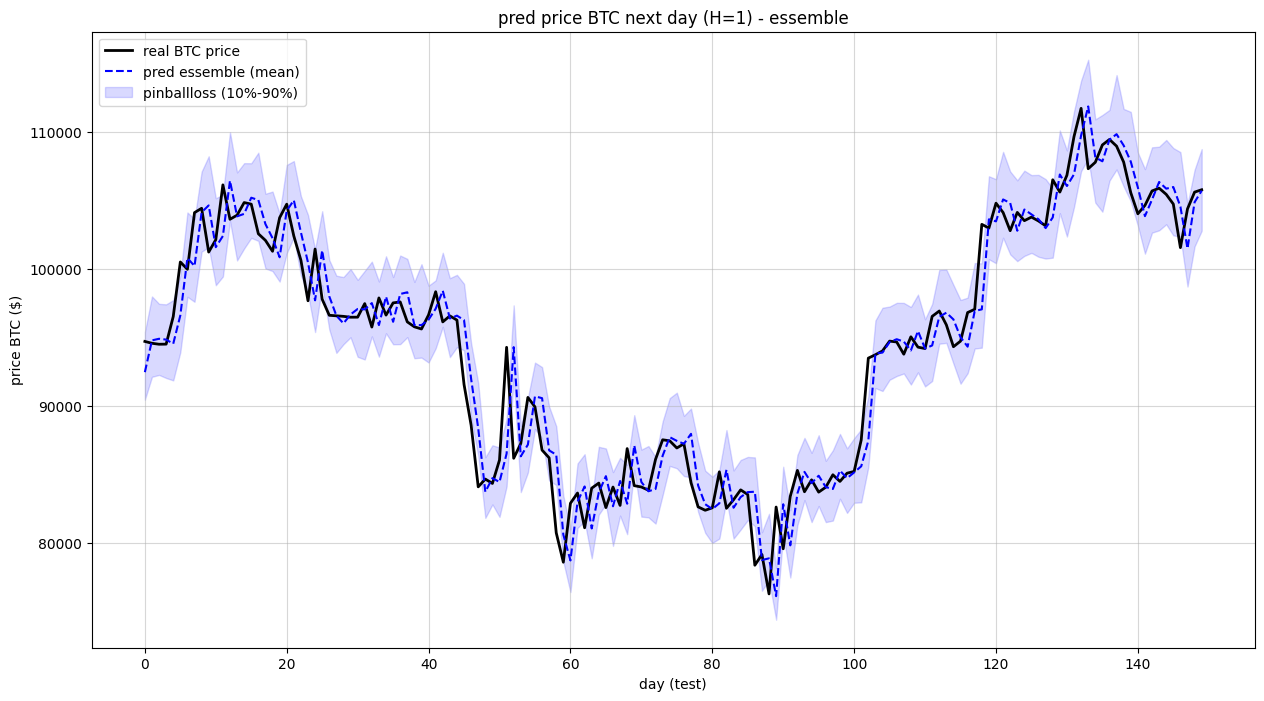

avg err (MAE): $1696.84


In [10]:
lstm_model.load_state_dict(torch.load('best_model_LSTM.pth'))
linear_model.load_state_dict(torch.load('best_model_Linear.pth'))

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            preds = model(x)
            all_preds.append(preds.cpu().numpy())
    return np.concatenate(all_preds, axis=0)

lstm_preds_scaled = get_predictions(lstm_model, test_loader)
linear_preds_scaled = get_predictions(linear_model, test_loader)

lstm_returns = scaler_Y.inverse_transform(lstm_preds_scaled)
linear_returns = scaler_Y.inverse_transform(linear_preds_scaled)

ensemble_returns = (lstm_returns + linear_returns) / 2

test_start_idx = len(X) - len(X_test)
dataset_indices = range(len(test_dataset))

base_prices = []
true_future_prices = []

common_dates = df_merged.index
btc_prices_series = btc_absolute_prices.reindex(common_dates)['Close']

for i in dataset_indices:
    global_idx_end_window = test_start_idx + i + WINDOW_SIZE - 1
    
    base_date = common_dates[global_idx_end_window]
    
    target_date = common_dates[global_idx_end_window + 1]
    
    price_t = btc_prices_series.loc[base_date]
    base_prices.append(price_t)
    
    price_t_plus_1 = btc_prices_series.loc[target_date]
    true_future_prices.append(price_t_plus_1)

base_prices = np.array(base_prices).reshape(-1, 1)
true_future_prices = np.array(true_future_prices).reshape(-1, 1)

pred_price_ensemble = base_prices * np.exp(ensemble_returns)
pred_price_lstm = base_prices * np.exp(lstm_returns)

plt.figure(figsize=(15, 8))

zoom = slice(-150, None) 

plt.plot(true_future_prices[zoom], label='real BTC price', color='black', linewidth=2)

plt.plot(pred_price_ensemble[zoom, 1], label='pred essemble (mean)', color='blue', linestyle='--')

plt.fill_between(
    range(len(true_future_prices[zoom])),
    pred_price_ensemble[zoom, 0],
    pred_price_ensemble[zoom, 2],
    color='blue', alpha=0.15, label='pinballloss (10%-90%)'
)

plt.title('pred price BTC next day (H=1) - essemble')
plt.xlabel('day (test)')
plt.ylabel('price BTC ($)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

mae_ensemble = np.mean(np.abs(pred_price_ensemble[:, 1] - true_future_prices.flatten()))
print(f"avg err (MAE): ${mae_ensemble:.2f}")

In [11]:
btc_ret_H2 = btc_ret.copy()
btc_ret_H2[TARGET_COL_H2] = btc_ret_H2['BTC_Close'].shift(-PREDICT_HORIZON_H2)

In [12]:
df_merged_H2 = btc_ret_H2.join(df_sol_ret, how='inner').join(df_eth_ret, how='inner').dropna()

In [13]:
X_H2 = df_merged_H2.drop(columns=[TARGET_COL_H2])
Y_H2 = df_merged_H2[TARGET_COL_H2]

In [14]:
scaler_X_H2 = MinMaxScaler(feature_range=(-1, 1))
X_scaled_H2 = pd.DataFrame(scaler_X_H2.fit_transform(X_H2), columns=X_H2.columns, index=X_H2.index)

In [15]:
scaler_Y_H2 = MinMaxScaler(feature_range=(-1, 1))
Y_scaled_H2 = scaler_Y_H2.fit_transform(Y_H2.values.reshape(-1, 1)).flatten()
Y_scaled_H2 = pd.Series(Y_scaled_H2, index=Y_H2.index)

In [16]:
X_train_H2, Y_train_H2, X_val_H2, Y_val_H2, X_test_H2, Y_test_H2 = sequential_split(
    X_scaled_H2, Y_scaled_H2, TEST_SIZE, VAL_SIZE
)

In [17]:
train_dataset_H2 = TimeSeriesDataset(X_train_H2, Y_train_H2, WINDOW_SIZE_H2)
val_dataset_H2 = TimeSeriesDataset(X_val_H2, Y_val_H2, WINDOW_SIZE_H2)
test_dataset_H2 = TimeSeriesDataset(X_test_H2, Y_test_H2, WINDOW_SIZE_H2)

train_loader_H2 = DataLoader(train_dataset_H2, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_H2 = DataLoader(val_dataset_H2, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader_H2 = DataLoader(test_dataset_H2, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [18]:
input_dim_H2 = X_train_H2.shape[1]

In [19]:
def train_model_H2(model_class, name_prefix):
    
    if name_prefix == "LSTM_H2":
        model = QuantileLSTM(input_dim_H2, HIDDEN_SIZE, NUM_LAYERS, DROPOUT_RATE, len(QUANTILE_CONFIG)).to(DEVICE)
    else:
        model = LinearBenchmark(WINDOW_SIZE_H2 * input_dim_H2, len(QUANTILE_CONFIG)).to(DEVICE)
        
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = PinballLoss(QUANTILE_CONFIG)
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss_accum = 0
        for x_batch, y_batch in train_loader_H2:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss_accum += loss.item()
            
        avg_train_loss = train_loss_accum / len(train_loader_H2)
        
        model.eval()
        val_loss_accum = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader_H2:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss_accum += loss_fn(model(x_batch), y_batch).item()
                
        avg_val_loss = val_loss_accum / len(val_loader_H2)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'best_model_{name_prefix}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping epoch {epoch+1}")
                break
                
    print(f"train {name_prefix} end. best Val Loss: {best_val_loss:.5f}")
    return model

In [20]:
lstm_model_H2 = train_model_H2(QuantileLSTM, "LSTM_H2")
linear_model_H2 = train_model_H2(LinearBenchmark, "Linear_H2")

Early stopping epoch 33
train LSTM_H2 end. best Val Loss: 0.03411
train Linear_H2 end. best Val Loss: 0.03467


In [21]:
lstm_model_H2.load_state_dict(torch.load('best_model_LSTM_H2.pth'))
linear_model_H2.load_state_dict(torch.load('best_model_Linear_H2.pth'))

<All keys matched successfully>

In [22]:
lstm_preds_scaled_H2 = get_predictions(lstm_model_H2, test_loader_H2)
linear_preds_scaled_H2 = get_predictions(linear_model_H2, test_loader_H2)

In [23]:
lstm_returns_H2 = scaler_Y_H2.inverse_transform(lstm_preds_scaled_H2)
linear_returns_H2 = scaler_Y_H2.inverse_transform(linear_preds_scaled_H2)

In [24]:
ensemble_returns_H2 = (lstm_returns_H2 + linear_returns_H2) / 2

In [30]:
btc_absolute_prices_H2 = btc_absolute_prices.copy()

In [31]:
PREDICT_HORIZON_H2 = 2
test_start_idx_H2 = len(X_H2) - len(X_test_H2)
common_dates_H2 = df_merged_H2.index
btc_prices_series_H2 = btc_absolute_prices_H2.reindex(common_dates_H2)['Close']

In [32]:
base_prices_H2 = []
true_future_prices_H2 = []

In [33]:
N_PREDICTIONS_TO_KEEP = len(ensemble_returns_H2) - PREDICT_HORIZON_H2 
dataset_indices_H2 = range(N_PREDICTIONS_TO_KEEP)

In [34]:
ensemble_returns_H2_valid = ensemble_returns_H2[:N_PREDICTIONS_TO_KEEP]

In [35]:
for i in dataset_indices_H2:
    global_idx_end_window_merged = test_start_idx_H2 + i + WINDOW_SIZE - 1
    
    base_date = common_dates_H2[global_idx_end_window_merged]
    
    base_price_full_index = btc_absolute_prices_H2.index.get_loc(base_date)
    
    target_date_full_index = base_price_full_index + PREDICT_HORIZON_H2
    target_date = btc_absolute_prices_H2.index[target_date_full_index]
    
    price_t = btc_prices_series_H2.loc[base_date]
    base_prices_H2.append(price_t)
    
    price_t_plus_2 = btc_absolute_prices_H2['Close'].loc[target_date]
    true_future_prices_H2.append(price_t_plus_2)

In [36]:
base_prices_H2 = np.array(base_prices_H2).reshape(-1, 1)
true_future_prices_H2 = np.array(true_future_prices_H2).reshape(-1, 1)

pred_price_ensemble_H2 = base_prices_H2 * np.exp(ensemble_returns_H2_valid)

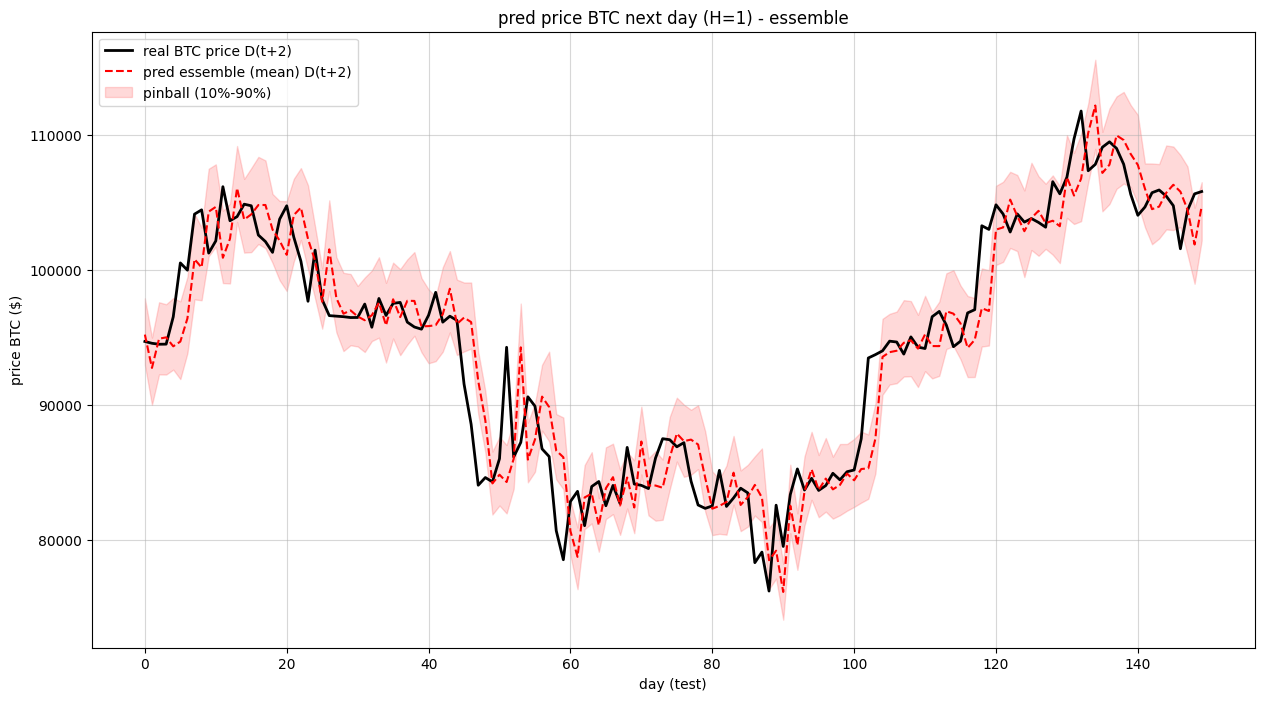

avg err MAE H=1: $1696.84
avg err MAE H=2: $2333.71


In [37]:
plt.figure(figsize=(15, 8))

zoom = slice(-150, None) 

plt.plot(true_future_prices_H2[zoom], label='real BTC price D(t+2)', color='black', linewidth=2)
plt.plot(pred_price_ensemble_H2[zoom, 1], label='pred essemble (mean) D(t+2)', color='red', linestyle='--')

plt.fill_between(
    range(len(true_future_prices_H2[zoom])),
    pred_price_ensemble_H2[zoom, 0], 
    pred_price_ensemble_H2[zoom, 2], 
    color='red', alpha=0.15, label='pinball (10%-90%)'
)

plt.title('pred price BTC next day (H=1) - essemble')
plt.xlabel('day (test)')
plt.ylabel('price BTC ($)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

mae_ensemble_H2 = np.mean(np.abs(pred_price_ensemble_H2[:, 1] - true_future_prices_H2.flatten()))

print(f"avg err MAE H=1: ${mae_ensemble:.2f}") 
print(f"avg err MAE H=2: ${mae_ensemble_H2:.2f}")

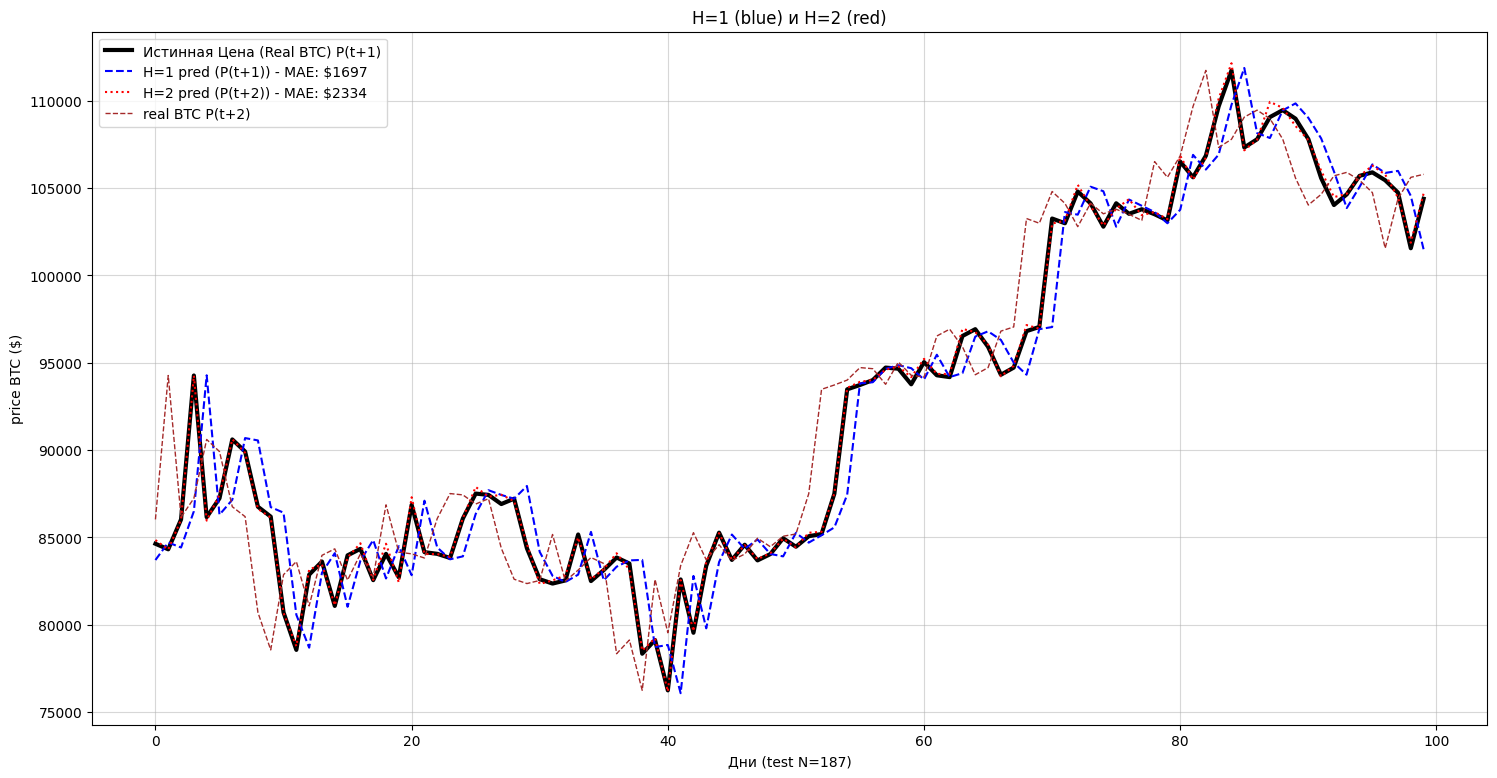

In [41]:
_ = true_future_prices
_ = pred_price_ensemble

_ = true_future_prices_H2
_ = pred_price_ensemble_H2

_ = mae_ensemble
_ = mae_ensemble_H2

N_H1 = len(true_future_prices)
N_H2 = len(true_future_prices_H2)
N_min = min(N_H1, N_H2)

true_H1 = true_future_prices[:N_min]
pred_H1_median = pred_price_ensemble[:N_min, 1]

true_H2 = true_future_prices_H2[:N_min]
pred_H2_median = pred_price_ensemble_H2[:N_min, 1]

plt.figure(figsize=(18, 9))

zoom = slice(-100, None)

plt.plot(true_H1[zoom], label='Истинная Цена (Real BTC) P(t+1)', color='black', linewidth=3)

plt.plot(pred_H1_median[zoom], label=f'H=1 pred (P(t+1)) - MAE: ${mae_ensemble:.0f}', color='blue', linestyle='--')

plt.plot(pred_H2_median[zoom], label=f'H=2 pred (P(t+2)) - MAE: ${mae_ensemble_H2:.0f}', color='red', linestyle=':')

plt.plot(true_H2[zoom], label='real BTC P(t+2)', color='brown', linewidth=1, linestyle='--') 


plt.title('H=1 (blue) и H=2 (red)')
plt.xlabel(f'Дни (test N={N_min})')
plt.ylabel('price BTC ($)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)
plt.show()